In [9]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit, cross_validate
from ElectricSequentialRegressor import ElectricSequentialRegressor
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor
from scipy.stats import randint, uniform
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, r2_score, make_scorer
from Utils import mse_column_score, plot_performance_analysis, shifted_mape
import joblib

In [4]:
X = pd.read_csv('dataset/dataset_in.txt', index_col=0).drop(columns=['P2', 'Q2'])
y_columns = [f'V{i}' for i in range(2,15)] + ['PERD', 'QGEN7'] #V1 ES SIEMPRE 1.0 EN DATASET
Y = pd.read_csv('dataset/dataset_out.txt', index_col=0).loc[:, y_columns]
#FILTRAR DATOS ERRÓNEOS (PÉRDIDAS NEGATIVAS)
mask = Y['PERD'] >= 0
X = X[mask]
Y = Y[mask]
#NORMALIZACIÓN DE ATRIBUTOS PARA FACILITAR COMPARACIÓN ENTRE MODELOS
normalizer_X = MinMaxScaler(feature_range=(0, 1))
X = pd.DataFrame(normalizer_X.fit_transform(X), columns=X.columns, index=X.index)

In [5]:
n_samples = X.shape[0]
train_size = int(n_samples * 0.8)
x_train, y_train = X[:train_size], Y[:train_size]
x_test, y_test = X[train_size:], Y[train_size:]

In [12]:
random_model = ElectricSequentialRegressor(XGBRegressor(objective='reg:squarederror', n_jobs=1, random_state=42),
                                           MultiOutputRegressor(XGBRegressor(objective='reg:squarederror', n_jobs=1, random_state=42), n_jobs=1))
random_grid = {
    'estimator1__n_estimators': randint(30, 101),
    'estimator1__max_depth': randint(3, 9),
    'estimator1__learning_rate': uniform(0.01, 0.2),
    'estimator1__colsample_bytree': uniform(0.4, 0.5),
    'estimator2__estimator__n_estimators': randint(80, 251),
    'estimator2__estimator__max_depth': randint(4, 11),
    'estimator2__estimator__learning_rate': uniform(0.01, 0.2),
    'estimator2__estimator__colsample_bytree': uniform(0.4, 0.5)
}
random_scoring = {
    'mse_global': 'neg_mean_squared_error',
    'mse_v_perd': make_scorer(mse_column_score, col_idx=[c for c in range(0, Y.shape[1] - 1)], greater_is_better=False),
    'mse_qgen7': make_scorer(mse_column_score, col_idx=-1, greater_is_better=False),
}
random_search = RandomizedSearchCV(random_model, random_grid, n_iter=30,
                                   cv=TimeSeriesSplit(n_splits=3), scoring=random_scoring, refit='mse_global',
                                   n_jobs=-1, verbose=2, random_state=42, return_train_score=True)

In [13]:
random_search.fit(x_train, y_train)

Fitting 3 folds for each of 30 candidates, totalling 90 fits


,estimator,ElectricSeque... n_jobs=1))
,param_distributions,"{'estimator1__colsample_bytree': <scipy.stats....001E84FB8B090>, 'estimator1__learning_rate': <scipy.stats....001E84FB8A910>, 'estimator1__max_depth': <scipy.stats....001E84CAB3210>, 'estimator1__n_estimators': <scipy.stats....001E84FB24790>, ...}"
,n_iter,30
,scoring,"{'mse_global': 'neg_mean_squared_error', 'mse_qgen7': make_scorer(m...', col_idx=-1), 'mse_v_perd': make_scorer(m..., 11, 12, 13])}"
,n_jobs,-1
,refit,'mse_global'
,cv,TimeSeriesSpl...est_size=None)
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [15]:
best_random_model = random_search.best_estimator_
print('MSE: ' + str(random_search.best_score_))
random_results = pd.DataFrame(random_search.cv_results_)
random_results.loc[:, ['param_estimator1__max_depth', 'param_estimator1__colsample_bytree', 'param_estimator1__learning_rate', 'param_estimator1__n_estimators', 'param_estimator2__estimator__max_depth', 'param_estimator2__estimator__colsample_bytree', 'param_estimator2__estimator__learning_rate', 'param_estimator2__estimator__n_estimators', 'mean_test_mse_global', 'mean_test_mse_v_perd', 'mean_test_mse_qgen7']]

MSE: -0.009919484766821066


,param_estimator1__max_depth,param_estimator1__colsample_bytree,param_estimator1__learning_rate,param_estimator1__n_estimators,param_estimator2__estimator__max_depth,param_estimator2__estimator__colsample_bytree,param_estimator2__estimator__learning_rate,param_estimator2__estimator__n_estimators,mean_test_mse_global,mean_test_mse_v_perd,mean_test_mse_qgen7
0,5,0.587270,0.200143,90,10,0.698425,0.099167,154,-0.017849,-0.019101,-0.000315
1,5,0.629624,0.076742,51,9,0.428206,0.154400,117,-0.016742,-0.017913,-0.000341
2,3,0.400389,0.208442,87,4,0.662378,0.096389,138,-0.018319,-0.019603,-0.000338
3,6,0.599930,0.019333,44,6,0.628035,0.167035,187,-0.011911,-0.012681,-0.001137
4,5,0.657117,0.128483,80,5,0.740154,0.100100,211,-0.010389,-0.011108,-0.000314
5,4,0.871101,0.122658,38,7,0.407983,0.056179,190,-0.013599,-0.014546,-0.000332
6,5,0.741632,0.131999,65,9,0.491118,0.161072,213,-0.015835,-0.016943,-0.000314
7,7,0.503971,0.123540,92,5,0.821142,0.099951,93,-0.020174,-0.021593,-0.000320
8,8,0.763636,0.075308,91,5,0.562665,0.087735,190,-0.011675,-0.012486,-0.000312
9,6,0.814369,0.081351,89,10,0.671348,0.038185,124,-0.023988,-0.025680,-0.000307


In [16]:
random_predictions = best_random_model.predict(x_test)
random_MAE = mean_absolute_error(y_test, random_predictions, multioutput='raw_values')
#DESPLAZAMIENTO PARA EVITAR DIVISIÓN POR VALORES CERCANO A 0. CONSECUENCIA: MAPE ALGO OPTIMISTA
random_MAPE = mean_absolute_percentage_error(y_test + 1.0, random_predictions + 1.0, multioutput='raw_values')
random_R2 = r2_score(y_test, random_predictions, multioutput='raw_values')
random_data_score = np.vstack([random_MAE, random_MAPE, random_R2])
pd.DataFrame(random_data_score, columns=y_columns, index=['MAE', 'MAPE', 'R2'])

,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,PERD,QGEN7
MAE,0.001716,0.001729,0.001735,0.001737,0.001736,0.001736,0.001731,0.001731,0.001732,0.001737,0.001725,0.001315,0.001311,0.236427,0.016979
MAPE,0.000870,0.000877,0.000880,0.000881,0.000881,0.000881,0.000878,0.000878,0.000879,0.000881,0.000875,0.000664,0.000662,0.026941,0.015958
R2,0.973149,0.973134,0.973211,0.973220,0.973269,0.973265,0.973363,0.973346,0.973301,0.973322,0.973524,0.980613,0.980702,0.977467,0.796058


In [18]:
random_search.best_params_

{'estimator1__colsample_bytree': np.float64(0.4165253664502742),
 'estimator1__learning_rate': np.float64(0.0790142496053366),
 'estimator1__max_depth': 3,
 'estimator1__n_estimators': 48,
 'estimator2__estimator__colsample_bytree': np.float64(0.7403527257773834),
 'estimator2__estimator__learning_rate': np.float64(0.11618691666342727),
 'estimator2__estimator__max_depth': 5,
 'estimator2__estimator__n_estimators': 239}

In [19]:
evaluate_model = ElectricSequentialRegressor(XGBRegressor(objective='reg:squarederror', colsample_bytree=0.8, learning_rate=0.075, max_depth=6, n_estimators=80, n_jobs=1, random_state=42),
                                           MultiOutputRegressor(XGBRegressor(objective='reg:squarederror', colsample_bytree=0.74, learning_rate=0.116, max_depth=5, n_estimators=239, n_jobs=1, random_state=42), n_jobs=1))
evaluate_scoring = {
    'mse': 'neg_mean_squared_error',
    'mae': 'neg_mean_absolute_error',
    'mape': make_scorer(shifted_mape, greater_is_better=False),
    'r2': 'r2'
}
evaluate_results = cross_validate(evaluate_model, X, Y, scoring=evaluate_scoring, cv=TimeSeriesSplit(n_splits=5), n_jobs=-1)
print('MSE: ' + str(-evaluate_results['test_mse'].mean()))
print('MAE: ' + str(-evaluate_results['test_mae'].mean()))
print('MAPE: ' + str(-evaluate_results['test_mape'].mean()))
print('R2: ' + str(evaluate_results['test_r2'].mean()))

MSE: 0.011500229220837354
MAE: 0.01837330386042595
MAPE: 0.003058795943784981
R2: 0.9705559134483337


In [20]:
evaluate_model = ElectricSequentialRegressor(XGBRegressor(objective='reg:squarederror', colsample_bytree=0.8, learning_rate=0.075, max_depth=6, n_estimators=80, n_jobs=1, random_state=42),
                                           MultiOutputRegressor(XGBRegressor(objective='reg:squarederror', colsample_bytree=0.74, learning_rate=0.116, max_depth=5, n_estimators=239, n_jobs=1, random_state=42), n_jobs=1))
evaluate_model.fit(x_train, y_train)

,estimator1,"XGBRegressor(...ree=None, ...)"
,estimator2,MultiOutputRe... n_jobs=1)
,pivot_col_index,-1
,n_jobs,None
,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8


In [21]:
evaluate_predictions = evaluate_model.predict(x_test)
evaluate_MAE = mean_absolute_error(y_test, evaluate_predictions, multioutput='raw_values')
#DESPLAZAMIENTO PARA EVITAR DIVISIÓN POR VALORES CERCANO A 0. CONSECUENCIA: MAPE ALGO OPTIMISTA
evaluate_MAPE = mean_absolute_percentage_error(y_test + 1.0, evaluate_predictions + 1.0, multioutput='raw_values')
evaluate_R2 = r2_score(y_test, evaluate_predictions, multioutput='raw_values')
evaluate_data_score = np.vstack([evaluate_MAE, evaluate_MAPE, evaluate_R2])
pd.DataFrame(evaluate_data_score, columns=y_columns, index=['MAE', 'MAPE', 'R2'])

,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,PERD,QGEN7
MAE,0.001679,0.001692,0.001693,0.001695,0.001696,0.001695,0.001691,0.001693,0.001686,0.001696,0.001692,0.001311,0.001314,0.233227,0.006938
MAPE,0.000851,0.000858,0.000859,0.000860,0.000860,0.000860,0.000858,0.000859,0.000855,0.000860,0.000858,0.000663,0.000664,0.026724,0.006531
R2,0.974040,0.974070,0.974268,0.974251,0.974241,0.974205,0.974275,0.974155,0.974446,0.974211,0.974366,0.980707,0.980576,0.977939,0.885745


In [23]:
joblib.dump(evaluate_model, 'modelos/ESR_MO_XGBoost.pkl')

['modelos/ESR_MO_XGBoost.pkl']

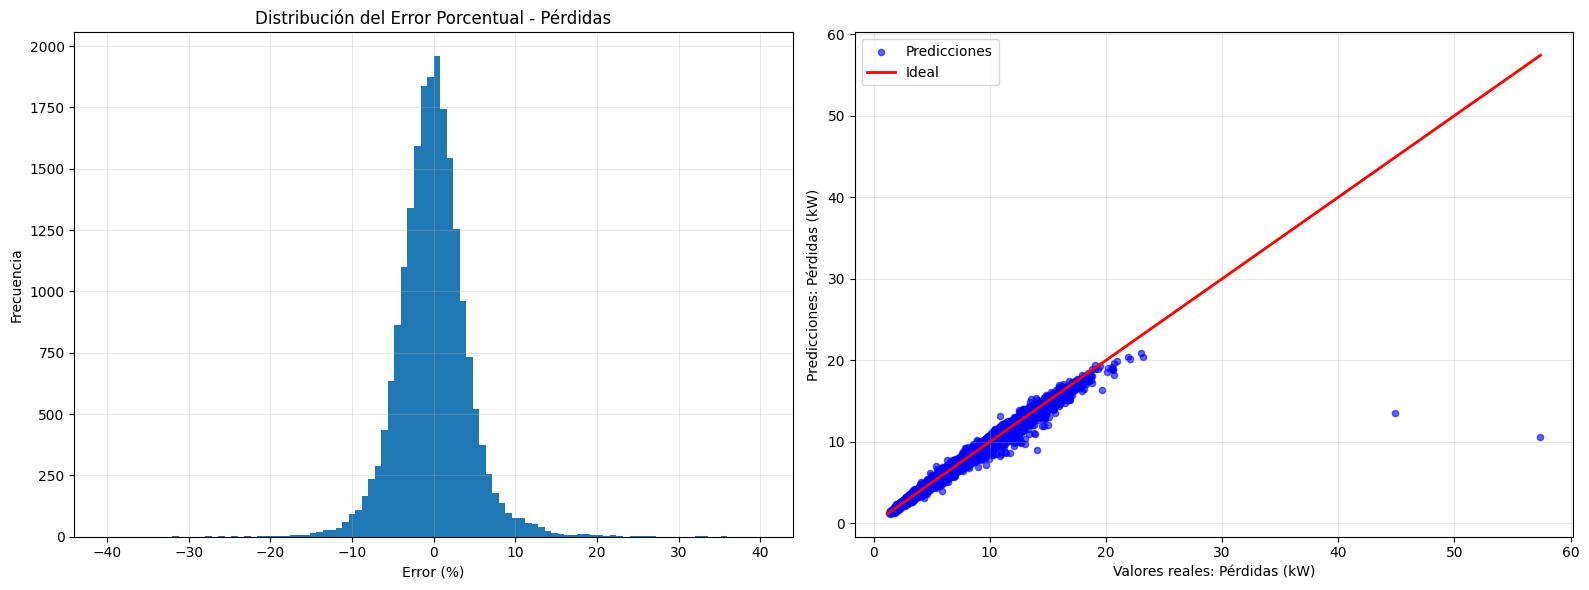

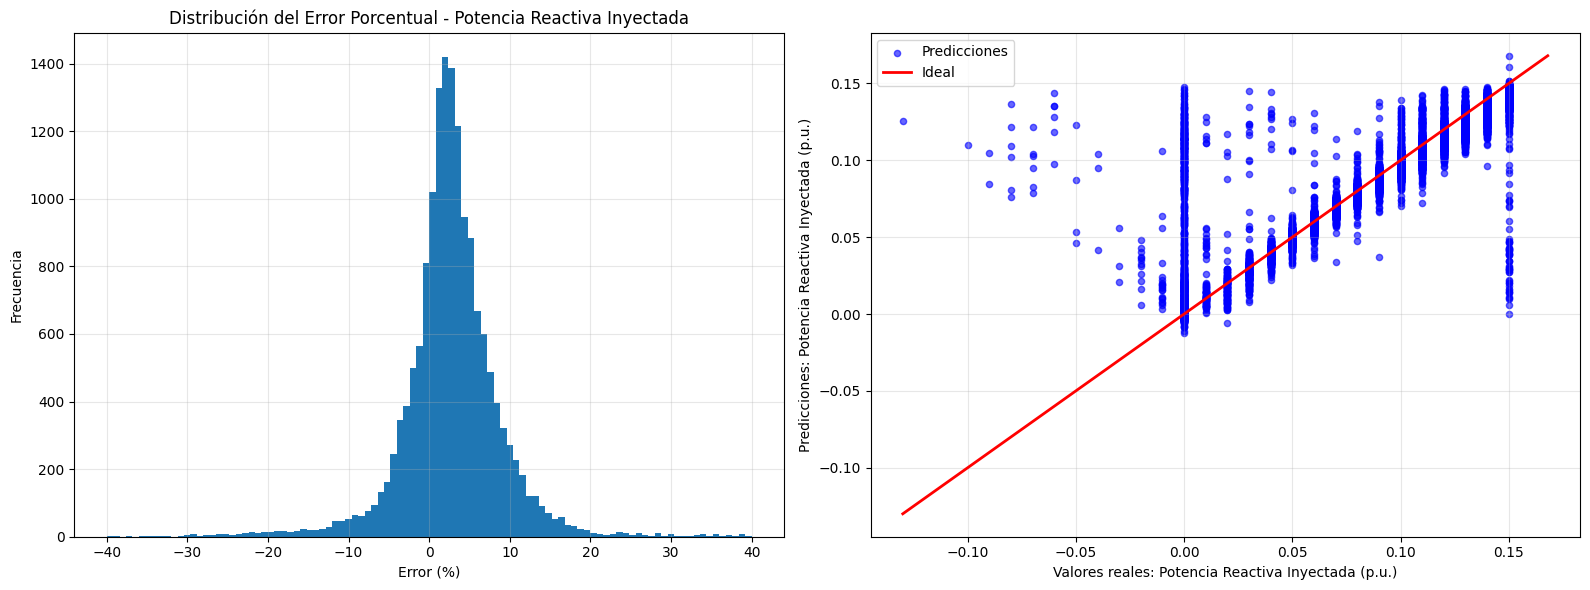

In [24]:
plot_performance_analysis(
    y_test['PERD'],
    evaluate_predictions[:, -2],
    variable_name="Pérdidas",
    unit_label="kW"
)

plot_performance_analysis(
    y_test['QGEN7'],
    evaluate_predictions[:, -1],
    variable_name="Potencia Reactiva Inyectada",
    unit_label="p.u."
)